In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, precision_score, recall_score, accuracy_score,
                              average_precision_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Load the train/test splits we saved in Phase 4
X_train = joblib.load('../data/processed/X_train.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"\nTrain fraud: {(y_train == 1).sum():,}  |  Test fraud: {(y_test == 1).sum():,}")

X_train: (454902, 30)  |  y_train: (454902,)
X_test:  (56962, 30)   |  y_test:  (56962,)

Train fraud: 227,451  |  Test fraud: 98


In [3]:
# Random Forest = an ensemble of many decision trees voting together.
# - n_estimators: how many trees (more = better but slower)
# - max_depth: how deep each tree can grow (prevents overfitting)
# - n_jobs=-1: use ALL CPU cores (this is a must for speed)

print("🌲 Training Random Forest... (this will take 2-5 minutes)")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"\n✅ Training done in {elapsed:.1f} seconds ({elapsed/60:.1f} min)")

🌲 Training Random Forest... (this will take 2-5 minutes)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   13.9s



✅ Training done in 46.2 seconds (0.8 min)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   46.0s finished


In [4]:
# Predict on test set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # probabilities for class 1 (fraud)

# Calculate all key metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
pr_auc    = average_precision_score(y_test, y_proba)

print("=" * 60)
print("🎯 RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)
print(f"  Accuracy:     {accuracy*100:.3f}%")
print(f"  Precision:    {precision*100:.2f}%   (of predicted frauds, how many real?)")
print(f"  Recall:       {recall*100:.2f}%   (of real frauds, how many caught?)")
print(f"  F1-Score:     {f1:.4f}")
print(f"  ROC-AUC:      {roc_auc:.4f}")
print(f"  PR-AUC:       {pr_auc:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


🎯 RANDOM FOREST — TEST SET PERFORMANCE
  Accuracy:     99.921%
  Precision:    73.87%   (of predicted frauds, how many real?)
  Recall:       83.67%   (of real frauds, how many caught?)
  F1-Score:     0.7847
  ROC-AUC:      0.9516
  PR-AUC:       0.8577

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.74      0.84      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


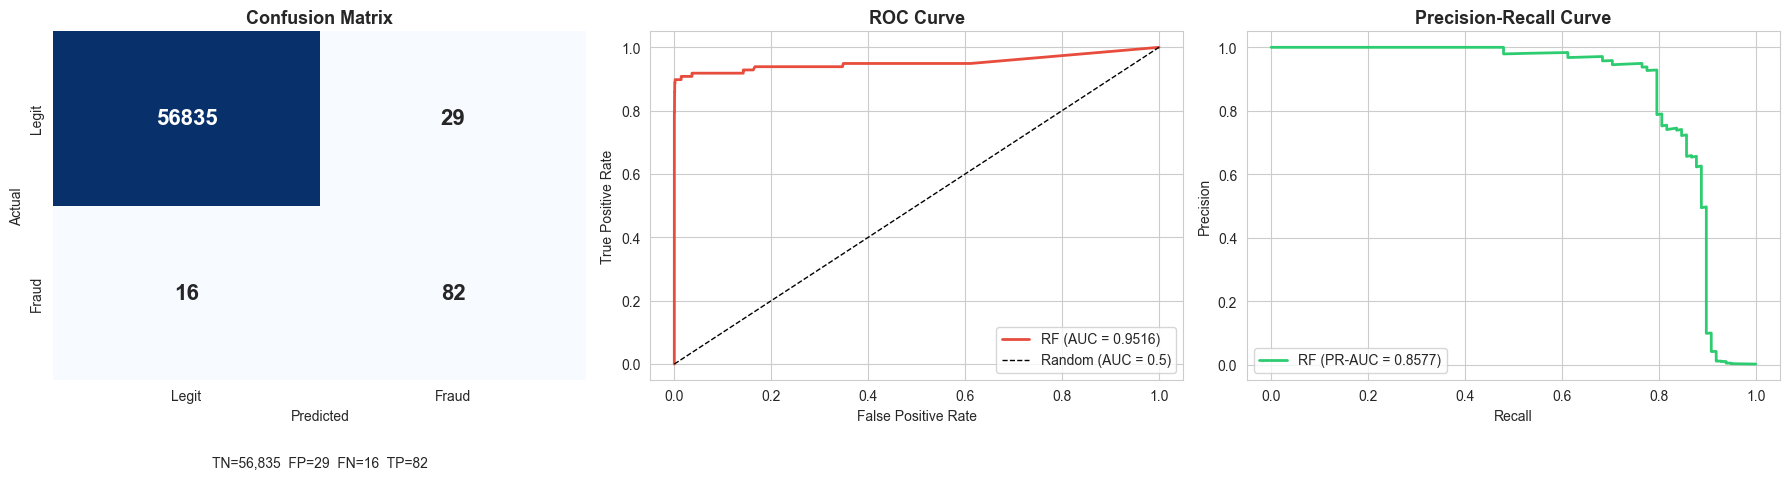


🔍 HOW TO READ THIS:
  • TN (56,835)  — legit correctly identified ✅
  • TP (82)    — FRAUD correctly caught ✅
  • FP (29)    — legit wrongly flagged as fraud (customer annoyance) ⚠️
  • FN (16)    — FRAUD missed (money lost!) ❌



In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1️⃣ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
            cbar=False, annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn:,}  FP={fp}  FN={fn}  TP={tp}',
             ha='center', transform=axes[0].transAxes, fontsize=10)

# 2️⃣ ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'RF (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# 3️⃣ Precision-Recall curve (more informative for imbalanced data)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='#2ecc71', linewidth=2, label=f'RF (PR-AUC = {pr_auc:.4f})')
axes[2].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.savefig('../reports/06_random_forest_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
🔍 HOW TO READ THIS:
  • TN ({tn:,})  — legit correctly identified ✅
  • TP ({tp})    — FRAUD correctly caught ✅
  • FP ({fp})    — legit wrongly flagged as fraud (customer annoyance) ⚠️
  • FN ({fn})    — FRAUD missed (money lost!) ❌
""")

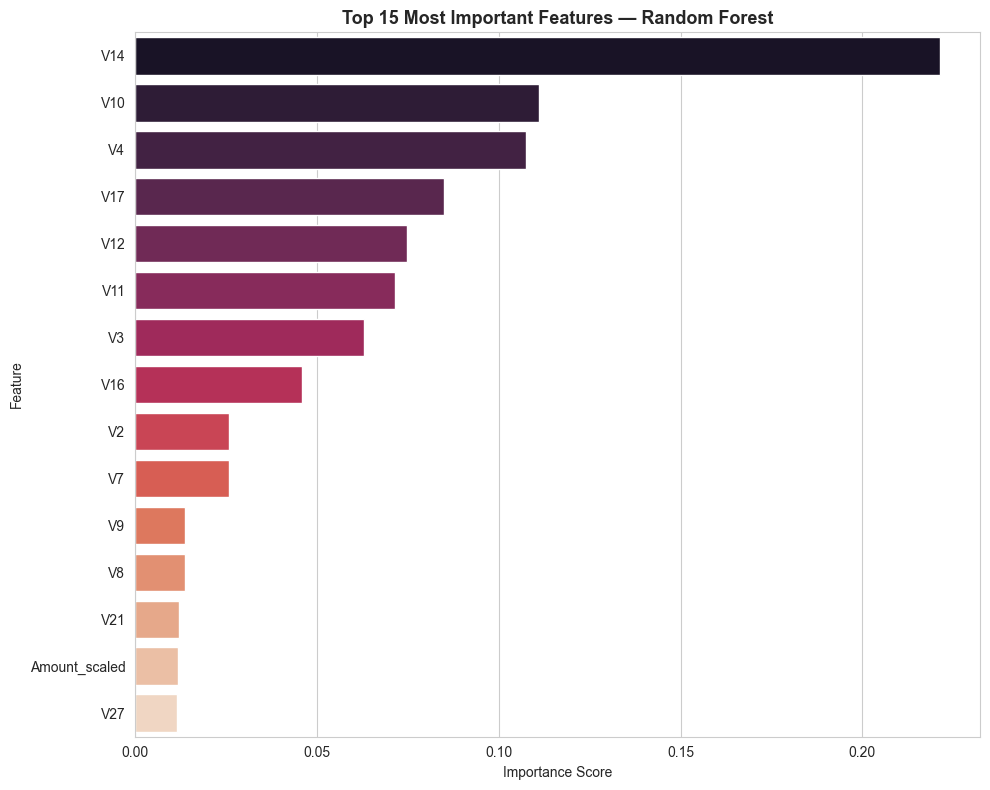

🎯 TOP 10 MOST IMPORTANT FEATURES:
Feature  Importance
    V14    0.221282
    V10    0.111130
     V4    0.107435
    V17    0.084917
    V12    0.074766
    V11    0.071472
     V3    0.063037
    V16    0.045861
     V2    0.025836
     V7    0.025808


In [6]:
# Which features does the model rely on most?
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='rocket')
plt.title('Top 15 Most Important Features — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/07_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("🎯 TOP 10 MOST IMPORTANT FEATURES:")
print(importances.head(10).to_string(index=False))

In [7]:
# Save the trained model to disk
joblib.dump(rf_model, '../models/random_forest.pkl')

# Save metrics to a dict (we'll compare all 3 models later)
rf_results = {
    'model_name': 'Random Forest',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'training_time_sec': elapsed,
    'confusion_matrix': cm.tolist(),
}
joblib.dump(rf_results, '../models/rf_results.pkl')

print("💾 Model saved to: models/random_forest.pkl")
print("💾 Metrics saved to: models/rf_results.pkl")
print("\n✅ PHASE 5 COMPLETE!")
print("🚀 Next: Phase 6 — XGBoost (usually the best model)")

💾 Model saved to: models/random_forest.pkl
💾 Metrics saved to: models/rf_results.pkl

✅ PHASE 5 COMPLETE!
🚀 Next: Phase 6 — XGBoost (usually the best model)
